In [1]:
# ANALISIS DE FACTORES QUIMICOS EN VINOS - Wine Quality Dataset
# Variante 7 | Programacion Cientifica
#Juan Carlos Concha Hernandez 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# exploramos la estructura del dataset para entender cuantas observaciones tenemos, que tipo de variables contiene y si existen valores faltantes que requieran tratamiento.

In [4]:
print("Forma del dataset:", df.shape)
print(f"El dataset contiene {df.shape[0]} vinos y {df.shape[1]} variables químicas")

Forma del dataset: (1599, 12)
El dataset contiene 1599 vinos y 12 variables químicas


In [5]:
#informacion completa del dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
# Estadísticas descriptivas de todas las variables químicas
df.describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


In [7]:
# Conteo de valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [8]:
#verificar el total de nulos en el dataset
print(f"Total de valores nulos en el dataset: {df.isnull().sum().sum()}")
print("\nDecisión: No se requiere aplicar fillna() ni dropna()")
print("ya que el dataset no presenta valores nulos en ninguna columna.")

Total de valores nulos en el dataset: 0

Decisión: No se requiere aplicar fillna() ni dropna()
ya que el dataset no presenta valores nulos en ninguna columna.


In [9]:
#El dataset no presenta valores faltantes en ninguna columna. Sin embargo, se procede a identificar valores atipicos mediante el metodo IQR (Rango Intercuartilico) para cada variable quimica.

In [10]:
# Detección de valores atípicos mediante método IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print("Cantidad de outliers por variable:")
print(outliers)

Cantidad de outliers por variable:
fixed acidity            49
volatile acidity         19
citric acid               1
residual sugar          155
chlorides               112
free sulfur dioxide      30
total sulfur dioxide     55
density                  45
pH                       35
sulphates                59
alcohol                  13
quality                  28
dtype: int64


In [11]:
# Porcentaje de outliers respecto al total
porcentaje = (outliers / len(df) * 100).round(2)
print("Porcentaje de outliers por variable (%):")
print(porcentaje)

Porcentaje de outliers por variable (%):
fixed acidity           3.06
volatile acidity        1.19
citric acid             0.06
residual sugar          9.69
chlorides               7.00
free sulfur dioxide     1.88
total sulfur dioxide    3.44
density                 2.81
pH                      2.19
sulphates               3.69
alcohol                 0.81
quality                 1.75
dtype: float64


In [12]:
# Verificamos que el dataset sigue completo
print(f"Filas antes de limpieza: 1599")
print(f"Filas después de revisión: {len(df)}")
print("Decisión: Se conservan los outliers ya que representan variaciones quimicas reales en vinos de distinta calidad.")

Filas antes de limpieza: 1599
Filas después de revisión: 1599
Decisión: Se conservan los outliers ya que representan variaciones quimicas reales en vinos de distinta calidad.


In [13]:
#Se detectaron outliers en todas las variables quimicas, siendo "azucar recidual" (9.69%) y "cloruros" (7.00%) las mas afectadas. Se decide conservar todos los registros ya que estos valores representan variaciones quimicas reales y legitimas entre vinos de distinta calidad por lo cual no son errores de medicion.El dataset queda con 1599 observaciones  listas para el analisis.

In [14]:
# Separar variable objetivo
X = df.drop(columns="quality")
y = df["quality"]

# Aplicar normalización Min-Max
scaler = MinMaxScaler()
X_normalizado = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("Datos normalizados (rango 0-1):")
print(X_normalizado.describe().round(3))

# Codificación de categorías de calidad
df["categoria"] = df["quality"].apply(lambda x:
    "Alta" if x >= 7 else ("Baja" if x <= 4 else "Media"))

print("\nDistribución de categorías de calidad:")
print(df["categoria"].value_counts())

Datos normalizados (rango 0-1):
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count       1599.000          1599.000     1599.000        1599.000   
mean           0.329             0.279        0.271           0.112   
std            0.154             0.123        0.195           0.097   
min            0.000             0.000        0.000           0.000   
25%            0.221             0.185        0.090           0.068   
50%            0.292             0.274        0.260           0.089   
75%            0.407             0.356        0.420           0.116   
max            1.000             1.000        1.000           1.000   

       chlorides  free sulfur dioxide  total sulfur dioxide   density  \
count   1599.000             1599.000              1599.000  1599.000   
mean       0.126                0.210                 0.143     0.490   
std        0.079                0.147                 0.116     0.139   
min        0.000                0.00

In [15]:
### Pregunta 1: ¿Cuál es la relación entre contenido de alcohol y calidad del vino?
# Correlación entre alcohol y quality
corr_alcohol = df[['alcohol', 'quality']].corr()
print("Correlación entre alcohol y calidad:")
print(corr_alcohol)

# Promedio de alcohol por nivel de calidad
print("\nPromedio de alcohol según nivel de calidad:")
print(df.groupby('quality')['alcohol'].mean().round(2))

Correlación entre alcohol y calidad:
          alcohol   quality
alcohol  1.000000  0.476166
quality  0.476166  1.000000

Promedio de alcohol según nivel de calidad:
quality
3     9.96
4    10.27
5     9.90
6    10.63
7    11.47
8    12.09
Name: alcohol, dtype: float64


In [16]:
#**Interpretación Pregunta 1:**
#La correlación entre alcohol y calidad es de 0.476, lo que indica una relación positiva moderada. Los vinos de calidad 8 promedian12.09% de alcohol, mientras los de calidad 3 solo 9.96%.Esto sugiere que el contenido alcohólico es un factor relevanteen la percepción de calidad del vino tinto.

In [17]:
# Pregunta 2: ¿Cómo afecta la acidez volátil a la calidad del vino?
# Correlación entre acidez volátil y calidad
corr_acid = df[['volatile acidity', 'quality']].corr()
print("Correlación entre acidez volátil y calidad:")
print(corr_acid)

# Promedio de acidez volátil por nivel de calidad
print("\nPromedio de acidez volátil según nivel de calidad:")
print(df.groupby('quality')['volatile acidity'].mean().round(3))

Correlación entre acidez volátil y calidad:
                  volatile acidity   quality
volatile acidity          1.000000 -0.390558
quality                  -0.390558  1.000000

Promedio de acidez volátil según nivel de calidad:
quality
3    0.885
4    0.694
5    0.577
6    0.497
7    0.404
8    0.423
Name: volatile acidity, dtype: float64


In [18]:
#**Interpretación Pregunta 2:**
#La acidez volátil presenta una correlación negativa de -0.391 con 
#la calidad. Los vinos de calidad 3 tienen en promedio 0.885 g/L 
#de acidez volátil, casi el doble que los de calidad 7 (0.404 g/L).
#Una acidez volátil alta genera sabores a vinagre, lo que 
#perjudica directamente la percepción de calidad del vino.

In [19]:
# Pregunta 3: ¿Qué características químicas muestran mayor variabilidad entre vinos de diferente calidad?

# Desviación estándar de cada variable por nivel de calidad
variabilidad = df.groupby('quality').std(numeric_only=True).round(3)
print("Variabilidad (desv. estándar) por nivel de calidad:")
print(variabilidad)

# ¿Qué variable tiene mayor variabilidad general?
print("\nVariabilidad global por variable (desv. estándar total):")
print(df.drop(columns=['quality', 'categoria']).std().round(3).sort_values(ascending=False))

Variabilidad (desv. estándar) por nivel de calidad:
         fixed acidity  volatile acidity  citric acid  residual sugar  \
quality                                                                 
3                1.771             0.331        0.251           1.402   
4                1.627             0.220        0.201           1.789   
5                1.564             0.165        0.180           1.360   
6                1.798             0.161        0.195           1.442   
7                1.992             0.145        0.194           1.372   
8                2.120             0.145        0.200           1.295   

         chlorides  free sulfur dioxide  total sulfur dioxide  density     pH  \
quality                                                                         
3            0.066                9.764                16.829    0.002  0.144   
4            0.076                9.026                27.583    0.002  0.181   
5            0.054               10.955

In [20]:
#**Interpretación Pregunta 3:**
#Las variables con mayor variabilidad global son total sulfur dioxide 
#(32.895) y free sulfur dioxide (10.460), lo que indica que los niveles 
#de dióxido de azufre difieren ampliamente entre vinos de distinta calidad.
#Por otro lado, density es la variable más estable (0.002), sugiriendo 
#que la densidad es similar en todos los vinos independiente de su calidad.
#Esto indica que los sulfitos son factores químicos clave que diferencian 
#vinos de alta y baja calidad.

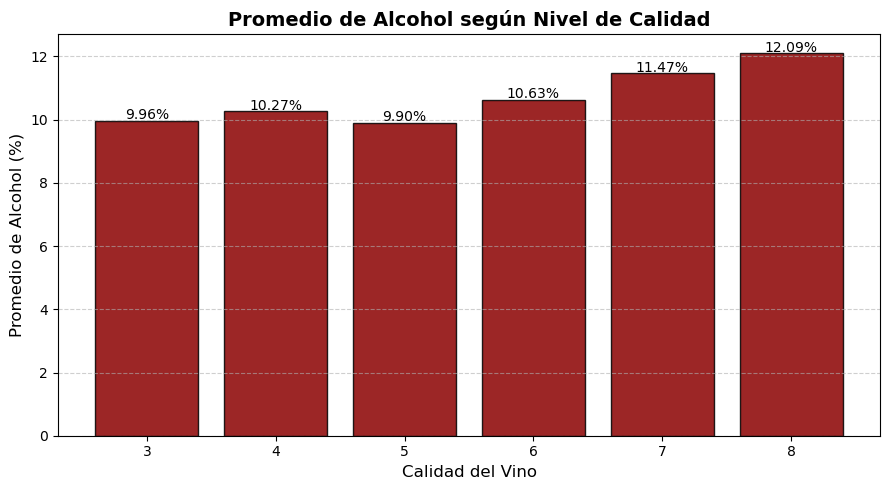

In [21]:
#Gráfico 1 (Matplotlib): Relación entre Alcohol y Calidad del Vino
fig, ax = plt.subplots(figsize=(9, 5))

# Promedio de alcohol por calidad
alcohol_por_calidad = df.groupby('quality')['alcohol'].mean()

ax.bar(alcohol_por_calidad.index, alcohol_por_calidad.values, 
       color='darkred', edgecolor='black', alpha=0.85)

ax.set_xlabel('Calidad del Vino', fontsize=12)
ax.set_ylabel('Promedio de Alcohol (%)', fontsize=12)
ax.set_title('Promedio de Alcohol según Nivel de Calidad', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.6)

for i, v in zip(alcohol_por_calidad.index, alcohol_por_calidad.values):
    ax.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('grafico1_alcohol_calidad.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
#Interpretación Gráfico 1:
#El gráfico de barras muestra el promedio de contenido alcohólico 
#agrupado por nivel de calidad del vino. Se observa una tendencia 
#ascendente clara: los vinos de calidad 3 promedian 9.96% de alcohol, 
#mientras que los de calidad 8 alcanzan 12.09%. 

#La única excepción leve ocurre entre calidad 4 y 5 (10.27% vs 9.90%),
#posiblemente debido a que hay pocos vinos de calidad 4 en el dataset.

#**Conclusión:** A mayor contenido de alcohol, mayor es la calidad 
#percibida del vino tinto. El alcohol es el factor químico con mayor 
#influencia positiva sobre la calidad.

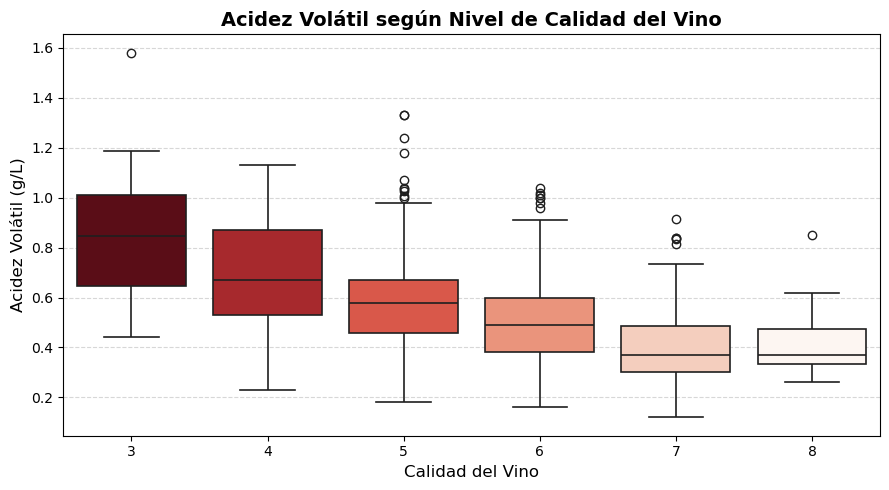

In [23]:
plt.figure(figsize=(9, 5))

sns.boxplot(x='quality', y='volatile acidity', data=df, 
            hue='quality', palette='Reds_r', linewidth=1.2, legend=False)

plt.title('Acidez Volátil según Nivel de Calidad del Vino', 
          fontsize=14, fontweight='bold')
plt.xlabel('Calidad del Vino', fontsize=12)
plt.ylabel('Acidez Volátil (g/L)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('grafico2_acidez_calidad.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
### Interpretación Gráfico 2:
#El boxplot muestra la distribución de acidez volátil para cada nivel 
#de calidad. Se observa una tendencia descendente muy clara: los vinos 
#de calidad 3 presentan valores medianos cercanos a 0.85 g/L, mientras 
#que los de calidad 7 y 8 bajan a valores cercanos a 0.40 g/L.

#Además, los vinos de baja calidad (3 y 4) muestran cajas más anchas,
#indicando mayor variabilidad en su acidez. Los puntos fuera de los 
#bigotes representan outliers — vinos con acidez extremadamente alta 
#o baja para su categoría.

#**Conclusión:** La acidez volátil es un factor perjudicial para la 
#calidad. Una acidez alta genera sabores indeseados similares al vinagre,
#lo que reduce la puntuación del vino. Los vinos premium mantienen 
#niveles bajos y consistentes de acidez volátil.

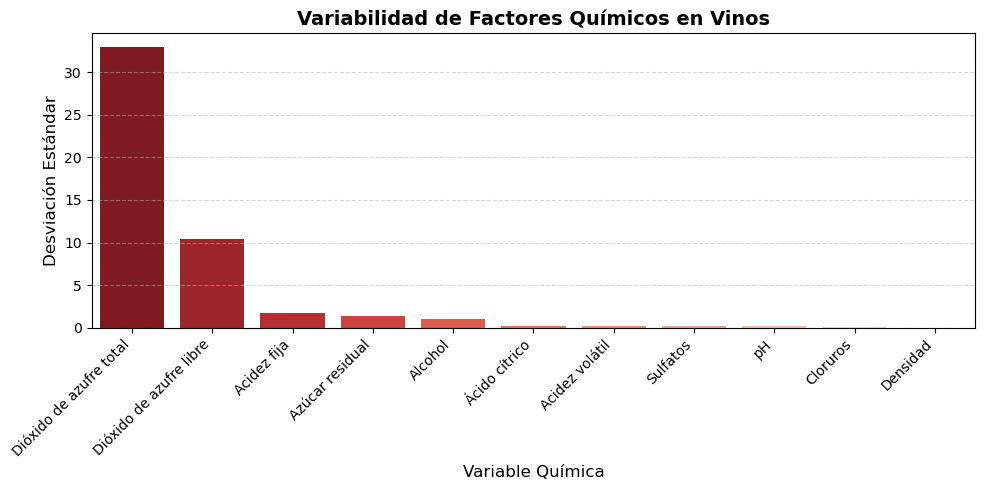

In [25]:
plt.figure(figsize=(10, 5))

variabilidad = df.drop(columns=['quality', 'categoria']).std().sort_values(ascending=False).reset_index()
variabilidad.columns = ['Variable', 'Desviacion_Estandar']
traducciones = {
    'total sulfur dioxide': 'Dióxido de azufre total',
    'free sulfur dioxide': 'Dióxido de azufre libre',
    'fixed acidity': 'Acidez fija',
    'residual sugar': 'Azúcar residual',
    'alcohol': 'Alcohol',
    'citric acid': 'Ácido cítrico',
    'volatile acidity': 'Acidez volátil',
    'sulphates': 'Sulfatos',
    'pH': 'pH',
    'chlorides': 'Cloruros',
    'density': 'Densidad'
}

variabilidad['Variable'] = variabilidad['Variable'].map(traducciones)

sns.barplot(x='Variable', y='Desviacion_Estandar', 
            data=variabilidad,
            hue='Variable',
            palette='Reds_r',
            legend=False)

plt.title('Variabilidad de Factores Químicos en Vinos',
          fontsize=14, fontweight='bold')
plt.xlabel('Variable Química', fontsize=12)
plt.ylabel('Desviación Estándar', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('grafico3_variabilidad.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
#interpretacion del grafico 3
#como podemos notar ne base a la desviacion estandar la variable con mayor variabilidad es el dioxido de azufre total en el vino,
#luego la sige el dioxido de azufre libre, asi tambien podemos notar que la densidad tiene una linea tan delgada que es casi inperceptible
#esto quiere decir que la densidad es  igual en todos los vinos que fueron analizados sin importar su calidad.